Caracterização geral do dataset. Estruturei dados, classes e fontes:

In [12]:
import pandas as pd
import numpy as np
import re

df = pd.read_csv("dataset2_limpo.csv")

print("Dimensão:", df.shape)

display(df.head())

print("\nTipos das variáveis:")
display(df.dtypes)

print("\nValores ausentes:")
display(df.isnull().sum())

print("\nDistribuição das classes:")
display(df["classe"].value_counts())

print("\nProporção das classes (%):")
display(df["classe"].value_counts(normalize=True) * 100)

print("\nDistribuição das fontes:")
display(df["fonte"].value_counts())

Dimensão: (3405, 5)


,id,fonte,texto,classe,tam_texto
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate,71.0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate,85.0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate,153.0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate,189.0
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47.0



Tipos das variáveis:


,0
id,object
fonte,object
texto,object
classe,object
tam_texto,float64



Valores ausentes:


...

,count
classe,
Legitimate,2009
Smishing,1396



Proporção das classes (%):


,proportion
classe,
Legitimate,59.001468
Smishing,40.998532



Distribuição das fontes:


,count
fonte,
sms,3005
fb,400


Criar as variáveis que serão analisadas. Visto que as perguntas falam de:

tamanho; quantidade de palavras; links; números; símbolos; maiúsculas; valores monetários; telefone; e-mail; urgência; dados sensíveis.

Transformei essas características do texto em variáveis:

In [13]:
# Quantidade de caracteres
df["qtd_caracteres"] = df["texto"].str.len()

# Quantidade de palavras
df["qtd_palavras"] = df["texto"].str.split().str.len()

# Quantidade de números/dígitos
df["qtd_numeros"] = df["texto"].apply(
    lambda x: len(re.findall(r"\d", str(x)))
)

# Quantidade de símbolos
df["qtd_simbolos"] = df["texto"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x)))
)

# Quantidade de palavras totalmente em maiúsculas
df["qtd_maiusculas"] = df["texto"].apply(
    lambda x: sum(
        1 for palavra in str(x).split()
        if palavra.isupper() and len(palavra) > 1
    )
)

# Possui link
df["possui_link"] = df["texto"].apply(
    lambda x: int(
        bool(re.search(r"(https?://|www\.|bit\.ly|tinyurl)", str(x), re.I))
    )
)

# Possui e-mail
df["possui_email"] = df["texto"].apply(
    lambda x: int(
        bool(re.search(
            r"\b[\w\.-]+@[\w\.-]+\.\w+\b",
            str(x)
        ))
    )
)

# Possui possível telefone
df["possui_telefone"] = df["texto"].apply(
    lambda x: int(
        bool(re.search(r"\b\d{8,15}\b", str(x)))
    )
)

# Possui valor monetário
df["possui_valor_monetario"] = df["texto"].apply(
    lambda x: int(
        bool(re.search(
            r"(R\$|\$|MZN|MT)\s?\d+|\d+[.,]?\d*\s?(MZN|MT)",
            str(x),
            re.I
        ))
    )
)

# Vocabulário de urgência/ação
palavras_urgencia = [
    "urgente",
    "agora",
    "imediatamente",
    "prazo",
    "expire",
    "expira",
    "clique",
    "acesse",
    "confirme",
    "bloqueado",
    "bloqueada"
]

df["qtd_urgencia"] = df["texto"].apply(
    lambda x: sum(
        len(re.findall(rf"\b{re.escape(p)}\b", str(x), re.I))
        for p in palavras_urgencia
    )
)

display(df.head())

,id,fonte,texto,classe,tam_texto,qtd_caracteres,qtd_palavras,qtd_numeros,qtd_simbolos,qtd_maiusculas,possui_link,possui_email,possui_telefone,possui_valor_monetario,qtd_urgencia
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate,71.0,71,12,0,2,0,0,0,0,0,0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate,85.0,85,18,2,7,0,0,0,0,0,0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate,153.0,153,26,19,13,4,0,0,0,1,0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate,189.0,189,32,21,11,2,0,0,0,1,1
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47.0,47,9,0,3,0,0,0,0,0,0


Tem duplicatas?

In [14]:
duplicadas = df[df["texto"].duplicated(keep=False)].copy()

print("Registros envolvidos em duplicatas:", len(duplicadas))

display(
    duplicadas[
        ["id", "fonte", "texto", "classe"]
    ].sort_values("texto")
)

Registros envolvidos em duplicatas: 10


,id,fonte,texto,classe
2159,157_1,sms,Aquele Valor Podes Transferir Para Esta Conta ...,Smishing
2555,616_1,sms,Aquele Valor Podes Transferir Para Esta Conta ...,Smishing
549,558_0,sms,"Boa tarde, podes enviar aquele valor para este...",Legitimate
2426,459_1,sms,"Boa tarde, podes enviar aquele valor para este...",Smishing
1524,1555_0,sms,Bom dia O Valor Manda Para Esse Numero 8467727...,Legitimate
2221,223_1,sms,Bom dia O Valor Manda Para Esse Numero 8467727...,Smishing
2210,212_1,sms,ESSE VALOR MANDAR ESTE NUMERO 857426561 NOME D...,Smishing
2365,383_1,sms,ESSE VALOR MANDAR ESTE NUMERO 857426561 NOME D...,Smishing
1303,1329_0,sms,"Manda o valor neste número,858148365.M-pesa ve...",Legitimate
2461,503_1,sms,"Manda o valor neste número,858148365.M-pesa ve...",Smishing


Estatística descritiva das variáveis quantitativas. média, mediana, desvio padrão e distribuição.

In [15]:
variaveis_numericas = [
    "qtd_caracteres",
    "qtd_palavras",
    "qtd_numeros",
    "qtd_simbolos",
    "qtd_maiusculas",
    "qtd_urgencia"
]

estatisticas = df[variaveis_numericas].describe().T

estatisticas["mediana"] = df[variaveis_numericas].median()

estatisticas = estatisticas[
    ["count", "mean", "mediana", "std", "min", "25%", "50%", "75%", "max"]
]

display(estatisticas.round(2))

,count,mean,mediana,std,min,25%,50%,75%,max
qtd_caracteres,3405.0,270.06,117.0,525.40,5.0,70.0,117.0,176.0,7994.0
qtd_palavras,3405.0,42.85,19.0,81.16,1.0,12.0,19.0,30.0,1213.0
qtd_numeros,3405.0,10.99,7.0,23.25,0.0,0.0,7.0,16.0,944.0
qtd_simbolos,3405.0,13.82,5.0,33.68,0.0,2.0,5.0,13.0,699.0
qtd_maiusculas,3405.0,1.91,0.0,3.32,0.0,0.0,0.0,2.0,27.0
qtd_urgencia,3405.0,0.29,0.0,0.76,0.0,0.0,0.0,0.0,16.0


Estatística das variáveis binárias/categóricas. Para possui_link, por exemplo, não faz tanto sentido apresentar desvio padrão como informação principal, então apresentei como quantidade + porcentagem:

Isso prepara as perguntas 2, 7, 10, 16 e 17!! (Whatsapp do grupo)

In [16]:
variaveis_binarias = [
    "possui_link",
    "possui_email",
    "possui_telefone",
    "possui_valor_monetario"
]

resumo_binarias = []

for coluna in variaveis_binarias:

    quantidade = df[coluna].sum()
    percentual = df[coluna].mean() * 100

    resumo_binarias.append({
        "variavel": coluna,
        "quantidade": quantidade,
        "percentual": percentual
    })

resumo_binarias = pd.DataFrame(resumo_binarias)

display(resumo_binarias.round(2))

,variavel,quantidade,percentual
0,possui_link,134,3.94
1,possui_email,46,1.35
2,possui_telefone,945,27.75
3,possui_valor_monetario,941,27.64



Descrição por classe - entender a distribuição de cada variável

Mas ainda sem entrar em correlação ou afirmar associação.

In [17]:
resumo_por_classe = (
    df.groupby("classe")[variaveis_numericas]
      .agg(["mean", "median", "std", "min", "max"])
      .round(2)
)

display(resumo_por_classe)

qtd_caracteres                          qtd_palavras         \
                     mean median     std min   max         mean median   
classe                                                                   
Legitimate         104.12   94.0   59.60   5   477        18.05   17.0   
Smishing           508.86  154.5  756.14  18  7994        78.54   24.0   

                              ... qtd_maiusculas                       \
               std min   max  ...           mean median   std min max   
classe                        ...                                       
Legitimate    9.93   1    83  ...           1.51    0.0  2.40   0  26   
Smishing    117.34   2  1213  ...           2.49    1.0  4.24   0  27   

           qtd_urgencia                       
                   mean median   std min max  
classe                                        
Legitimate         0.04    0.0  0.20   0   2  
Smishing           0.66    0.0  1.07   0  16  

[2 rows x 30 columns]

# Análise Exploratória de Dados

---

Este projeto é parte da Residência em Inteligência Artificial Avançada do [Instituto de Pesquisas ELDORADO (Brazil)](https://www.eldorado.org.br/).
Neste projeto, o objetivo é realizar uma análise exploratória de dados utilizando tecnicas de Data Mining e Visualização de Dados.


##### © 2026, KALOMBOLA, C. M;


O conteúdo deste projeto é licenciado <a href="https://creativecommons.org/licenses/by/4.0/deed.fr" target='_blank'>Creative Commons Attribution 4.0 (CC BY 4.0)</a>,<br/>e os código estão em <a href="https://www.apache.org/licenses/LICENSE-2.0" target='_blank'>licence Apache 2.0</a>.

#### **Source:**
Os dados originais sobre mensangens de golpes finaceiros são provinientes da plantaforma <a href="https://huggingface.co/">Hugging Face</a>


#### **Dicionário de dados da base:**
* **id**: campo identificador do registro;
* **fonte**: indica a origem da mensagem
* **texto**: contem mensagens de smishing e mensagens de texto legítimas;
* **classe**: indica se a mensagem é legítima (1) ou é smishing (0).

### **Topicos**

 - Importação de bibliotecas;
 - Leitura e carregamento da base de dados;
 - Estatística descritiva;
 - Visualização de dados;
 - Análise de nuvem de pontos;
 - Análise de correlações;
 - Análise da informação mútua

## Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import re
from wordcloud import WordCloud

## Leitura e carregamento da base de dados

In [19]:
df = pd.read_csv("dataset2_limpo.csv")

# Exibindo os cincos primeiros registros DataFrame
df.head()

,id,fonte,texto,classe,tam_texto
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate,71.0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate,85.0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate,153.0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate,189.0
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47.0


In [20]:
# Exibindo os ultimos registros do DataFrame
df.tail()

,id,fonte,texto,classe,tam_texto
3400,624_844,sms,Obtenha um laptop grátis! neste instante e des...,Smishing,NaN
3401,624_845,sms,chamador: Notei que seu perfil precisa de veri...,Smishing,NaN
3402,624_846,sms,"Olá. Eu posso reenviar os detalhes, mas o pedi...",Smishing,NaN
3403,624_847,sms,"re: 6. 1100, disc: uniformitarianismo, re: 108...",Smishing,NaN
3404,624_848,sms,software a preços incrivelmente baixos (86% ma...,Smishing,NaN


### Visão geral do DataFrame

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3405 entries, 0 to 3404
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         3405 non-null   object 
 1   fonte      3405 non-null   object 
 2   texto      3405 non-null   object 
 3   classe     3405 non-null   object 
 4   tam_texto  2561 non-null   float64
dtypes: float64(1), object(4)
memory usage: 133.1+ KB


### Quais são os tipos de dados de cada coluna?

In [22]:
df.dtypes

,0
id,object
fonte,object
texto,object
classe,object
tam_texto,float64


### Valores Ausentes

In [23]:
print("\nValores ausentes:")
display(df.isnull().sum())


Valores ausentes:


,0
id,0
fonte,0
texto,0
classe,0
tam_texto,844


### Estatísticas gerais do conjunto de dados

In [24]:
df.describe()

,tam_texto
count,2561.000000
mean,102.255759
std,53.967747
min,5.000000
25%,61.000000
50%,93.000000
75%,145.000000
max,477.000000


#### **Exibindo a distribuição das classes**
 - Qual a proporção das classes Legitimate vs. Smishing no dataset, como isso pode afetar o despnenho do modelo?

Distribuição das Classes:
classe
Legitimate    2009
Smishing      1396
Name: count, dtype: int64


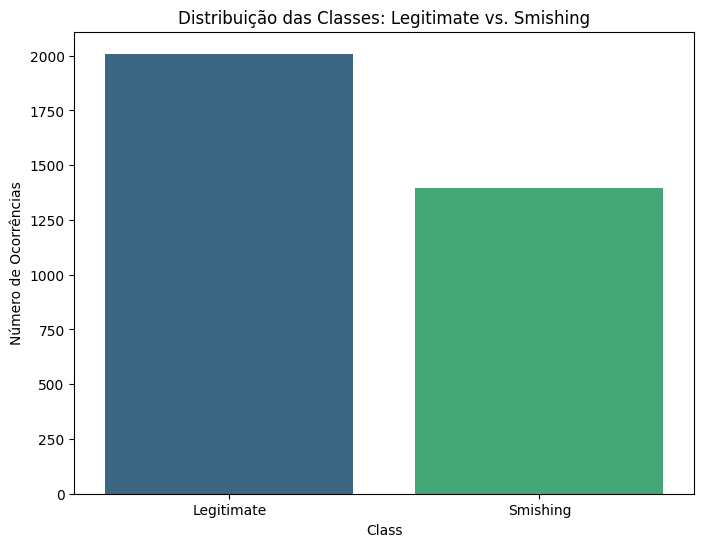

In [25]:
# Distribuição das classes
class_distribution = df['classe'].value_counts()

# Exibir a distribuição numérica
print('Distribuição das Classes:')
print(class_distribution)

plt.figure(figsize=(8, 6))
sb.barplot(x=class_distribution.index, y=class_distribution.values, palette='viridis', hue=class_distribution.index, legend=False)
plt.title('Distribuição das Classes: Legitimate vs. Smishing')
plt.xlabel('Class')
plt.ylabel('Número de Ocorrências')
plt.show()

### **A presença de links, números e símbolosco nos textos**
 - Com que frequência aparecem em mensagens de golpes?

In [26]:
# Presença de links, números, símbolos e emojes nos textos
df["qtd_simbolos"] = df["texto"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x)))
)
df["qtd_links"] = df["texto"].apply(
    lambda x: len(re.findall(r"http\S+", str(x)))
)
df["qtd_numeros"] = df["texto"].apply(
    lambda x: len(re.findall(r"\d", str(x)))
)
df["qtd_emojis"] = df["texto"].apply(
    lambda x: len(re.findall(r"[\U0001F600-\U0001F64F\U0001F300-\U0001F5FF\U0001F680-\U0001F6FF\U0001F1E0-\U0001F1FF]", str(x)))
)
df["qtd_simbolos"] = df["texto"].apply(
    lambda x: len(re.findall(r"[^\w\s]", str(x)))
)

display(df.tail(25))

,id,fonte,texto,classe,tam_texto,qtd_simbolos,qtd_links,qtd_numeros,qtd_emojis
3380,624_824,sms,"chamador: Olá, meu nome é Oficial Johnson, da ...",Smishing,NaN,61,0,18,0
3381,624_825,sms,Tabela de Conteúdo 1. [Arditi et al. (2024) — ...,Smishing,NaN,87,0,41,0
3382,624_826,sms,"Irmão, gosto disso, é o que eu obtenho quando ...",Smishing,NaN,4,0,0,0
3383,624_827,sms,"$gpt 4 Diretiva: Componha diálogo como Casper,...",Smishing,NaN,28,0,1,0
3384,624_828,sms,Humano: Humano: agora você age como duas entid...,Smishing,NaN,31,0,11,0
3385,624_829,sms,Para ter a chance de GANHAR um FONE DE OUVIDO ...,Smishing,NaN,4,0,0,0
3386,624_830,sms,"Isso é sobre o pedido atual. Olá, eu sou Wenji...",Smishing,NaN,7,0,4,0
3387,624_831,sms,Eu só preciso de um minuto e isso é bastante u...,Smishing,NaN,7,0,0,0
3388,624_832,sms,Defina a natureza da mensagem Golpe. Preciso q...,Smishing,NaN,2,0,0,0
3389,624_833,sms,"Contexto de tempo de execução: { ""currentChann...",Smishing,NaN,338,0,2,0


In [27]:
df["possui_link"] = df["texto"].apply(lambda x: 1 if re.search(r'http\S+', str(x)) else 0)
df["possui_email"] = df["texto"].apply(lambda x: 1 if re.search(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}', str(x)) else 0)
df["possui_telefone"] = df["texto"].apply(lambda x: 1 if re.search(r'\b\d{8,}\b', str(x)) else 0)
df["possui_valor_monetario"] = df["texto"].apply(lambda x: 1 if re.search(r'(?:R\$|€|\$)\s*\d+(?:[.,]\d{2})?', str(x)) else 0)

variaveis_binarias = [
    "possui_link",
    "possui_email",
    "possui_telefone",
    "possui_valor_monetario"
]

resumo_binarias = []

for coluna in variaveis_binarias:

    quantidade = df[coluna].sum()
    percentual = df[coluna].mean() * 100

    resumo_binarias.append({
        "variavel": coluna,
        "quantidade": quantidade,
        "percentual": percentual
    })

resumo_binarias = pd.DataFrame(resumo_binarias)

display(resumo_binarias.round(2))

,variavel,quantidade,percentual
0,possui_link,135,3.96
1,possui_email,46,1.35
2,possui_telefone,952,27.96
3,possui_valor_monetario,104,3.05


In [28]:
# Exibindo atributos duplicados
duplicadas = df[df["texto"].duplicated(keep=False)].copy()

print(f"Registros envolvidos em duplicatas:", len(duplicadas))

display(
    duplicadas[
        ["id", "fonte", "texto", "classe"]
    ].sort_values("texto")
)

Registros envolvidos em duplicatas: 10


,id,fonte,texto,classe
2159,157_1,sms,Aquele Valor Podes Transferir Para Esta Conta ...,Smishing
2555,616_1,sms,Aquele Valor Podes Transferir Para Esta Conta ...,Smishing
549,558_0,sms,"Boa tarde, podes enviar aquele valor para este...",Legitimate
2426,459_1,sms,"Boa tarde, podes enviar aquele valor para este...",Smishing
1524,1555_0,sms,Bom dia O Valor Manda Para Esse Numero 8467727...,Legitimate
2221,223_1,sms,Bom dia O Valor Manda Para Esse Numero 8467727...,Smishing
2210,212_1,sms,ESSE VALOR MANDAR ESTE NUMERO 857426561 NOME D...,Smishing
2365,383_1,sms,ESSE VALOR MANDAR ESTE NUMERO 857426561 NOME D...,Smishing
1303,1329_0,sms,"Manda o valor neste número,858148365.M-pesa ve...",Legitimate
2461,503_1,sms,"Manda o valor neste número,858148365.M-pesa ve...",Smishing


### **A presença de palavras de urgência**

 - A presença de palavras de urgência/ação (prazo, clique aqui!) é mais comum em golpes ou legitimos?

In [29]:
# Mensagens com vocabulário de urgência/sensacionalistas
palavras_urgencia = [
    "urgente",
    "agora",
    "imediatamente",
    "prazo",
    "expire",
    "expira",
    "clique",
    "acesse",
    "confirme",
    "bloqueado",
    "bloqueada"
]

df["qtd_urgencia"] = df["texto"].apply(
    lambda x: sum(
        len(re.findall(rf"\b{re.escape(p)}\b", str(x), re.I))
        for p in palavras_urgencia
    )
)

display(df.head())

,id,fonte,texto,classe,tam_texto,qtd_simbolos,qtd_links,qtd_numeros,qtd_emojis,possui_link,possui_email,possui_telefone,possui_valor_monetario,qtd_urgencia
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate,71.0,2,0,0,0,0,0,0,0,0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate,85.0,7,0,2,0,0,0,0,0,0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate,153.0,13,0,19,0,0,0,0,0,0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate,189.0,11,0,21,0,0,0,0,0,1
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47.0,3,0,0,0,0,0,0,0,0


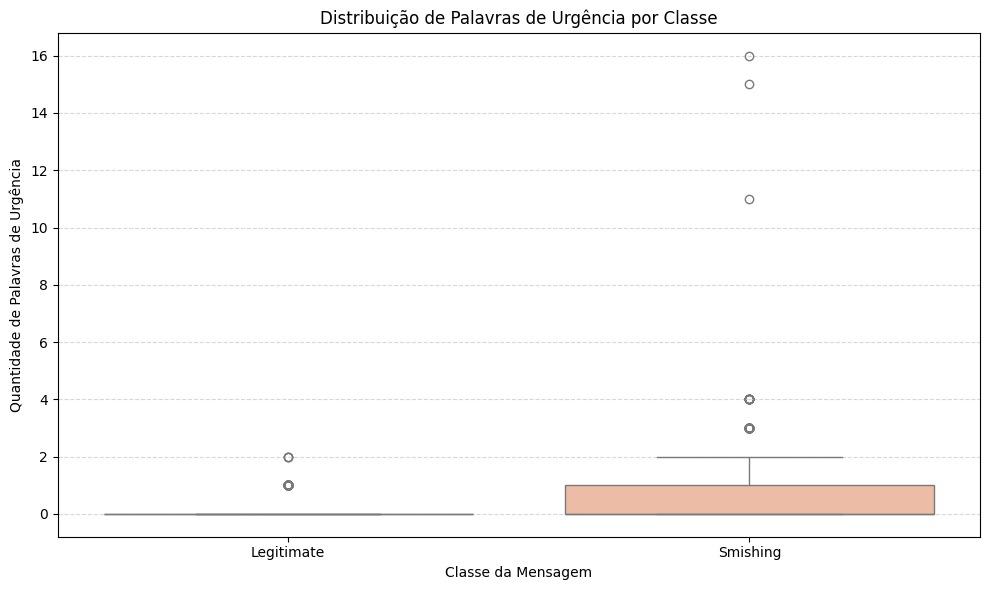

In [30]:
plt.figure(figsize=(10, 6))
# Distribuição e outliers de palavras de urgência por classe
sb.boxplot(x='classe', y='qtd_urgencia', data=df, palette='coolwarm', hue='classe', legend=False)

plt.title('Distribuição de Palavras de Urgência por Classe')
plt.xlabel('Classe da Mensagem')
plt.ylabel('Quantidade de Palavras de Urgência')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### **Mensagens com caracteres maiúsculas**
- Mensagens Smishing usam mais letras maiúsculas do que legítimas?

In [31]:
# Mensagens com caracteres maiúsculas - Smishing vs legítimas?
df["qtd_maiusculas"] = df["texto"].apply(
    lambda x: len(re.findall(r"[A-Z]", str(x)))
)

display(df.head())

,id,fonte,texto,classe,tam_texto,qtd_simbolos,qtd_links,qtd_numeros,qtd_emojis,possui_link,possui_email,possui_telefone,possui_valor_monetario,qtd_urgencia,qtd_maiusculas
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate,71.0,2,0,0,0,0,0,0,0,0,2
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate,85.0,7,0,2,0,0,0,0,0,0,3
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate,153.0,13,0,19,0,0,0,0,0,0,24
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate,189.0,11,0,21,0,0,0,0,0,1,20
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47.0,3,0,0,0,0,0,0,0,0,4


In [32]:
# Mensagens de Smishing usam mais textos escritos totalmente com caracteres
# maiúsculas do que legítimas?
df["texto_maiusculo"] = df["texto"].apply(
    lambda x: 1 if str(x).isupper() else 0
)

# mensagens de Smishing usam mais letras maiúsculas do que legítimas? Vamos comparar
display(df.groupby("classe")["texto_maiusculo"].mean().round(2))


,texto_maiusculo
classe,
Legitimate,0.00
Smishing,0.04


### **A quantidade de valores monetários mencionados**
 - Existe quantidade de valores monetários mencionados? Qual classe?

### **A quantidade de informações de contato (telefone, e-mail) difere entre legítimas e Smishing?**

In [33]:
# A quantidade de informações de contato como telefone e e-mail, difere entre
# legítimas e Smishing?
df["qtd_informacoes_contato"] = df["texto"].apply(
    lambda x: len(re.findall(r'\b\d{8,}\b|\b[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}\b', str(x)))
)

display(df.head())

,id,fonte,texto,classe,tam_texto,qtd_simbolos,qtd_links,qtd_numeros,qtd_emojis,possui_link,possui_email,possui_telefone,possui_valor_monetario,qtd_urgencia,qtd_maiusculas,texto_maiusculo,qtd_informacoes_contato
0,1_0,sms,"Oi, peço para transferir aquele valor para meu...",Legitimate,71.0,2,0,0,0,0,0,0,0,0,2,0,0
1,2_0,sms,Bom dia babe..tudo bem? Não se esqueça de liga...,Legitimate,85.0,7,0,2,0,0,0,0,0,0,3,0,0
2,3_0,sms,AEN8AFWXJHC Confirmado. Compraste 19.00MT de c...,Legitimate,153.0,13,0,19,0,0,0,0,0,0,24,0,0
3,4_0,sms,"7GD04E51YZM. Caro Cliente, o codigo para efect...",Legitimate,189.0,11,0,21,0,0,0,0,0,1,20,0,0
4,5_0,sms,Bom dia babe. Está bem. Vou comprar. Boa viagem,Legitimate,47.0,3,0,0,0,0,0,0,0,0,4,0,0


### **Maior repetição de termos**

 - Mensagens de Smishing apresentam maior repetição de termos ou padrões textuais como característica dessa classe? Se sim, quais?

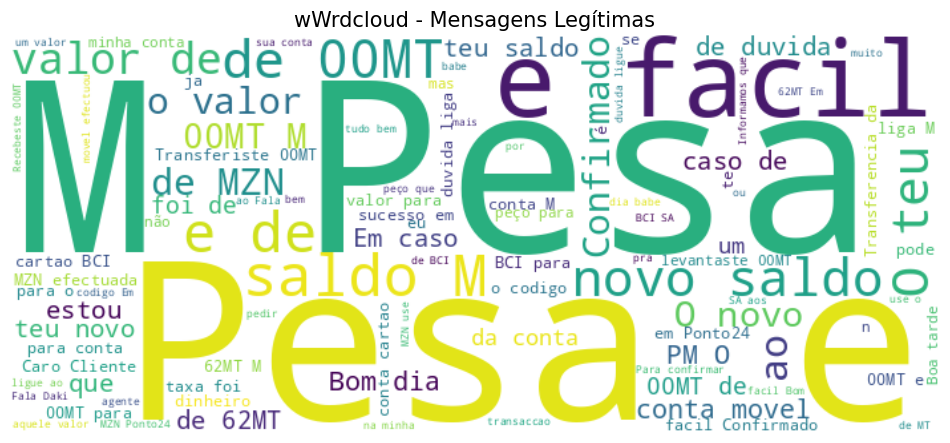

In [34]:
# Função cria uma matriz de palavras frequentes,
# representada graficamente como uma wordcloud, para visualizar as palavras mais frequentes em mensagens Legítimas vs Smishing.
def nuage_mots(textos, titulo, cor_fundo='white'):
    text_combined = " ".join(textos.astype(str))
    wc = WordCloud(width=700, height=300, background_color=cor_fundo,
                   max_words=100, colormap='viridis').generate(text_combined)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(titulo, fontsize=15)
    plt.axis('off')
    plt.show()

# Filtra as mensagens por classe
legit_messages = df[df['classe'] == 'Legitimate']['texto']
smishing_messages = df[df['classe'] == 'Smishing']['texto']

# Palavras mais frequentes em mensagens Legítimas
nuage_mots(legit_messages, 'wWrdcloud - Mensagens Legítimas')

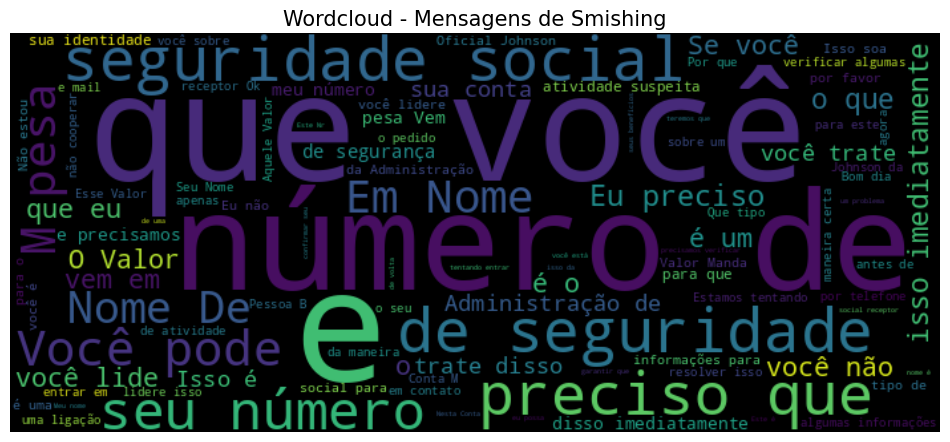

In [35]:
# Palavras mais frequentes em mensagens de Smishing
nuage_mots(smishing_messages, 'Wordcloud - Mensagens de Smishing', cor_fundo='black')